# Week12 - Short-term Stock Analysis
# ADV Python for DS

---




**Goal:**

Building and Testing multiple different machine learning algorithms to predict the price of the stock


**Dataset:**
A dataset built from Finnhub live data.

* Trades - Last Price Updates
Stream real-time trades for US stocks, forex and crypto. Trades might not be available for some forex and crypto exchanges. In that case, a price update will be sent with volume = 0. A message can contain multiple trades. 1 API key can only open 1 connection at a time.

The following FX brokers do not support streaming: FXCM, Forex.com, FHFX. To get latest price for FX, please use the Forex Candles or All Rates endpoint.



# **1) Check out the data**

**Import Libraries**

In [1]:
import requests
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [6]:
API_KEY = "d3bokn9r01qqg7bvg44gd3bokn9r01qqg7bvg450"   # free key at https://finnhub.io/
symbol = "AAPL"
url = f"https://finnhub.io/api/v1/quote?symbol={symbol}&token={API_KEY}"

prices = []

**Check out the Data**

In [22]:
print("Collecting last price data...")
for i in range(60):   # Collect 60 times (1 minute if interval=1s)
    data = requests.get(url).json()
    ts = pd.to_datetime(data["t"], unit="s")
    price = data["c"]
    prices.append({"time": ts, "price": price})
    print(f"[{ts}] {symbol}: {price}")
    time.sleep(1)   # Call every 1 second

df = pd.DataFrame(prices).dropna()
df.set_index("time", inplace=True)

[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00] AAPL: 255.46
[2025-09-26 20:00:00

In [29]:
# Display the first 5 rows
df.head(5)

,price,return,ma3,ma5,target
time,,,,,
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0


In [10]:
# Display 'information' about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 65 entries, 2025-09-26 20:00:00 to 2025-09-26 20:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   65 non-null     float64
dtypes: float64(1)
memory usage: 1.0 KB


None

In [11]:
# Display 'description' of the data in the DataFrame
display(df.describe())

,price
count,6.500000e+01
mean,2.554600e+02
std,4.296434e-13
min,2.554600e+02
25%,2.554600e+02
50%,2.554600e+02
75%,2.554600e+02
max,2.554600e+02


In [12]:
df.columns

Index(['price'], dtype='object')

# **2) Exploratory data analysis (EDA)**

In [30]:
df["return"] = df["price"].pct_change()
df["ma3"] = df["price"].rolling(3).mean()
df["ma5"] = df["price"].rolling(5).mean()


In [31]:
# Target: 1 = next price goes up, 0 = goes down
df["target"] = (df["price"].shift(-1) > df["price"]).astype(int)
df.dropna(inplace=True)


In [26]:
df

,price,return,ma3,ma5,target
time,,,,,
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0
...,...,...,...,...,...
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0
2025-09-26 20:00:00,255.46,0.0,255.46,255.46,0


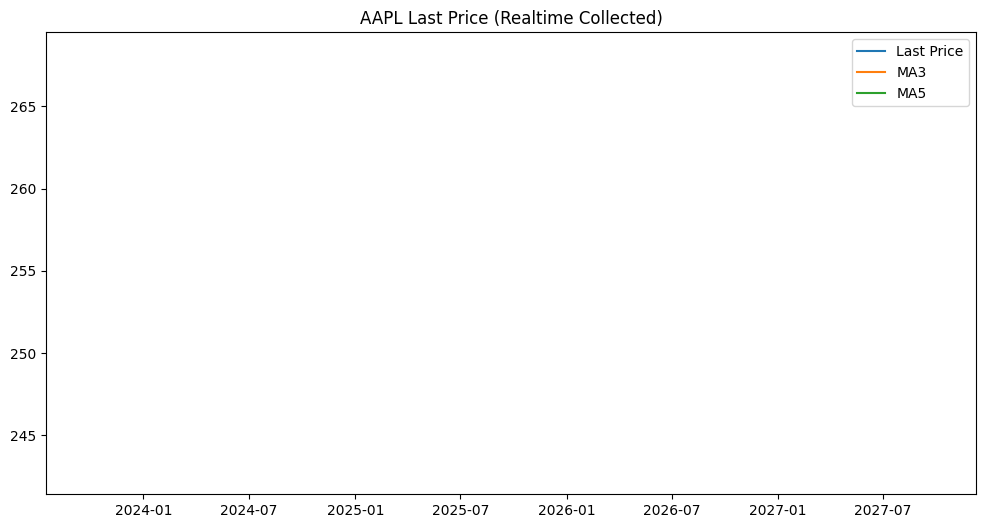

In [32]:
# Visualization

plt.figure(figsize=(12,6))

#Plot the following on the same graph:

#df["price"] as the Last Price

#df["ma3"] as the 3-day Moving Average (MA3)

#df["ma5"] as the 5-day Moving Average (MA5)

plt.plot(df.index,df["price"], label="Last Price")
plt.plot(df.index,df["ma3"], label="MA3")
plt.plot(df.index,df["ma5"], label="MA5")
plt.legend()
plt.title(f"{symbol} Last Price (Realtime Collected)")
plt.show()

# 3) Training a Model

In [28]:
X = df[["return", "ma3", "ma5"]]
y = df["target"]

**Train Test Split**

We will train out model on the training set and then use the test set to evaluate the model.

In [ ]:
#Tran and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Creating and Training the Model**

In [ ]:
#Create a ML model for a classification, Random Forest


In [ ]:
# Fit my model to my training data



In [ ]:
y_pred = model.predict(X_test)


# 4) Model Evaluation

Let's evaluate the model by checking out it's coefficients and how we can interpret them.

In [ ]:
print("Model Performance:\n")
print(classification_report(y_test, y_pred))

In [ ]:
last_data = X.iloc[-1:].values
pred = model.predict(last_data)[0]
print("\nPrediction for next tick:", "Price Up" if pred == 1 else "Price Down")

**Summary:**

This mini-project uses Finnhub’s free Last Price API to collect real-time stock prices (e.g., AAPL) and build a simple machine learning prediction model. The pipeline fetches live prices at fixed intervals, engineers features such as percentage return and moving averages, and creates a target variable indicating whether the next price tick will go up or down.

Using this dataset, a Random Forest classifier is trained to predict short-term price movement. The project includes visualization of price trends with moving averages and outputs both model performance metrics and a live prediction of whether the next tick will increase or decrease. It demonstrates how to turn streaming financial data into a real-time predictive analytics workflow.